# 9 Quantum Computing — Moons Classification

## 9.1
Follow the [PennyLane QNN tutorial](https://pennylane.ai/qml/demos/tutorial_qnn_module_torch) and create a quantum neural network to classify the Moons dataset.

## 9.2
Compare the quantum neural network to a classical neural network (without any quantum layer).

In [1]:
!pip install -q scikit-learn pennylane torch matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 55.6 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

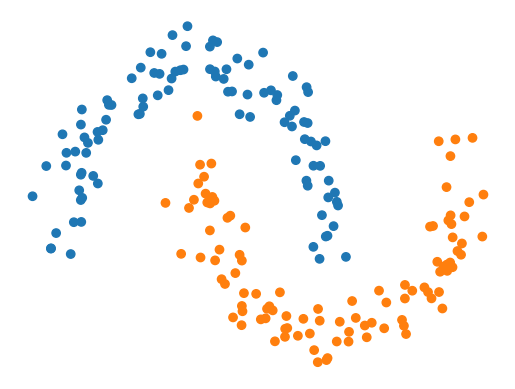

In [3]:
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

X, y = make_moons(n_samples=200, noise=0.1)
y_ = torch.unsqueeze(torch.tensor(y), 1)  # used for one-hot encoded labels
y_hot = torch.scatter(torch.zeros((200, 2)), 1, y_, 1)

c = ["#1f77b4" if y_ == 0 else "#ff7f0e" for y_ in y]  # colours for each class
plt.axis("off")
plt.scatter(X[:, 0], X[:, 1], c=c)
plt.show()

In [4]:
import pennylane as qml

n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

In [5]:
n_layers = 6
weight_shapes = {"weights": (n_layers, n_qubits)}
qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)
clayer_1 = nn.Linear(2, 2)
clayer_2 = nn.Linear(2, 2)

# Model 1 — Classical only (no quantum layer)

In [6]:
model1 = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 2), nn.Softmax(dim=1))
opt1 = torch.optim.SGD(model1.parameters(), lr=0.2)
loss_fn = nn.L1Loss()

# Prepare tensors (tutorial style)
X_all = torch.tensor(X, requires_grad=True).float()
y_hot_all = y_hot.float()
X_train, X_val = X_all[:150], X_all[150:]
y_train, y_val = y_hot_all[:150], y_hot_all[150:]

batch_size = 5
batches = 150 // batch_size
train_loader = torch.utils.data.DataLoader(
    list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True, drop_last=True
)

epochs = 6
for epoch in range(epochs):
    running_loss = 0
    for xs, ys in train_loader:
        opt1.zero_grad()
        loss_evaluated = loss_fn(model1(xs), ys)
        loss_evaluated.backward()
        opt1.step()
        running_loss += loss_evaluated
    avg_loss = running_loss / batches
    print("Average loss over epoch {}: {:.4f}".format(epoch + 1, avg_loss))

y_pred = model1(X_val)
predictions = torch.argmax(y_pred, axis=1).detach().numpy()
correct = [1 if p == p_true else 0 for p, p_true in zip(predictions, y[150:])]
accuracy = sum(correct) / len(correct)
print(f"Accuracy: {accuracy * 100}%")

Average loss over epoch 1: 0.5016
Average loss over epoch 2: 0.4960
Average loss over epoch 3: 0.4842
Average loss over epoch 4: 0.4452
Average loss over epoch 5: 0.3782
Average loss over epoch 6: 0.2986
Accuracy: 84.0%


# Model 2 — Hybrid quantum-classical (with quantum layer)

In [7]:
softmax = nn.Softmax(dim=1)
model2 = nn.Sequential(clayer_1, qlayer, clayer_2, softmax)
opt2 = torch.optim.SGD(model2.parameters(), lr=0.2)
loss_fn = nn.L1Loss()

In [8]:
epochs = 6
for epoch in range(epochs):
    running_loss = 0
    for xs, ys in train_loader:
        opt2.zero_grad()
        loss_evaluated = loss_fn(model2(xs), ys)
        loss_evaluated.backward()
        opt2.step()
        running_loss += loss_evaluated
    avg_loss = running_loss / batches
    print("Average loss over epoch {}: {:.4f}".format(epoch + 1, avg_loss))

y_pred = model2(X_val)
predictions = torch.argmax(y_pred, axis=1).detach().numpy()
correct = [1 if p == p_true else 0 for p, p_true in zip(predictions, y[150:])]
accuracy = sum(correct) / len(correct)
print(f"Accuracy: {accuracy * 100}%")

Average loss over epoch 1: 0.5021
Average loss over epoch 2: 0.4740
Average loss over epoch 3: 0.3824
Average loss over epoch 4: 0.2738
Average loss over epoch 5: 0.2138
Average loss over epoch 6: 0.1906
Accuracy: 82.0%


## **Comparison of results:**
   The classical model achieved about 84% accuracy, while the hybrid quantum-classical model achieved about 82%.  
   
**Observations:**
   - Both models were able to learn the nonlinear structure of the Moons dataset.
   - The classical model slightly outperformed the quantum model (84% vs 82%)
   - However, the quantum model started with a lower loss (0.5021 vs 0.5810)
     and converged faster in early epochs ( 6.epoch: 0.1906 vs 0.2986)

**Conclusion:**
This shows that adding a quantum layer does not automatically lead to better results
   